# Cross integration

**Cross integration** has several batches in which **all** modalities are present; the task is removing batch effects while keeping biological structure. Spatial registration (PASTE, PASTE2, SPIRAL, GPSA) also lives under `cross` - see the note at the end.

**Reference dataset:** `D52` (23,478 cells). The stored results
shipped with these notebooks were produced on it, so every table here
reproduces.

## 1. Install

Two layers: the `multibench` package (~2 MB) and the conda environments of the
methods you run. On **Colab**, run the first cell and let the kernel restart
once - then keep running from the next cell.

In [1]:
# Colab ships without conda; this provisions it (the kernel restarts ONCE).
# On a machine that already has conda, this cell does nothing.
import importlib.util, shutil

def _has(mod):
    try:
        return importlib.util.find_spec(mod) is not None
    except ModuleNotFoundError:
        return False

if shutil.which("conda") or shutil.which("mamba"):
    print("conda available - nothing to do")
elif _has("google.colab"):
    !pip -q install condacolab
    import condacolab
    condacolab.install()   # restarts the kernel; afterwards, continue below
else:
    print("no conda found - install it first (mamba recommended); see the installation guide")

conda available - nothing to do


In [2]:
import importlib.util, os
if importlib.util.find_spec("multibench") is None:
    !git clone --depth 1 https://github.com/DSichang/scMultiBench.git
    %cd scMultiBench
    !pip -q install -e .
elif os.path.isdir("/content/scMultiBench"):
    # reused Colab runtime: refresh the editable install to the latest code,
    # then drop the already-imported modules so the NEXT import sees it -
    # a live kernel never re-reads changed files on its own
    %cd /content/scMultiBench
    !git pull -q
    !pip -q install -e .
    import importlib, sys
    for _m in [m for m in list(sys.modules) if m == "multibench" or m.startswith("multibench.")]:
        del sys.modules[_m]
    importlib.invalidate_caches()
    print("multibench refreshed to the latest repository state")
else:
    print("multibench already installed")

multibench already installed


Now the environments for the methods this tutorial runs
(StabMap, UINMF, sciPENN). `--packed` downloads a prebuilt archive instead of
solving one from scratch, and `env install` skips anything already present.
Other tiers are one flag away: `--category cross` (~71 GB (11 envs)), or no flag
for the whole benchmark (29 envs, ~167 GB).

In [3]:
import sys
!{sys.executable} -m multibench env install --methods StabMap,UINMF,sciPENN --packed --run

scmb_r             [have          ] <- StabMap, UINMF
env_sciPENN        [have          ] <- sciPENN


In [4]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
from pathlib import Path
import pandas as pd
pd.set_option("display.max_colwidth", None)   # never truncate a `reason`
pd.set_option("display.max_columns", None)    # never hide a metric column
pd.set_option("display.width", 200)
import multibench as mtb

DATASET  = "D52"
CATEGORY = "cross"
RESULTS = Path("results") if Path("results").exists() else Path("notebooks/results")
mtb.data.fetch('D52')   # reference data (179 MB); no-op when present
print("multibench", mtb.__version__)

multibench 0.2.1


## 2. Run the analysis

One call is the whole pipeline: resolve each method's inputs, run it in its own
conda env, load the embeddings, score them with scIB metrics. Here
UINMF, sciPENN, StabMap. StabMap is among the fastest cross methods - `run_sec` in the summary is the measured time on our host.

In [5]:
res = mtb.run_all("D52", CATEGORY,
                  methods=['UINMF', 'sciPENN', 'StabMap'],
                  out_dir="/tmp/tutorial_cross")
res.summary

[run_all] StabMap (cross/D52) ...


[run_all]   -> CHAIN_OK (46.5s) 0.688


[run_all] UINMF (cross/D52) ...


[run_all]   -> CHAIN_OK (52.9s) 0.6905


[run_all] sciPENN (cross/D52) ...


[run_all]   -> CHAIN_OK (41.3s) 0.7347


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,StabMap,CHAIN_OK,46.5,embedding,"[23478, 50]",0,cty3.csv+cty1.csv+cty2.csv,0.8400,0.6880,0.7760,0.5569,0.5656,0.6811,0.9940,0.9241,0.9313,0.5208,None
1,UINMF,CHAIN_OK,52.9,embedding,"[14764, 30]",0,cty1.csv+cty2.csv,0.9996,0.6905,0.7772,0.5668,0.5553,0.6639,0.9933,0.9353,0.9296,0.8664,None
2,sciPENN,CHAIN_OK,41.3,embedding,"[23478, 512]",0,cty1.csv+cty2.csv+cty3.csv,0.8069,0.7347,0.8034,0.6085,0.6198,0.7253,0.9977,0.8760,0.9200,0.3618,None


The result object plots itself in the paper's layout:

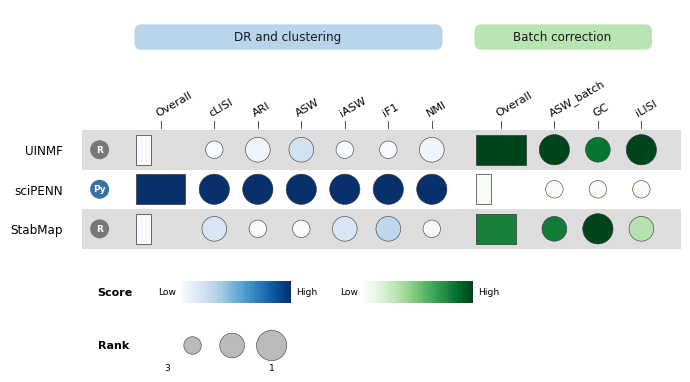

In [6]:
res.plot()

Each circle carries two encodings: its **size is the method's rank** in
that column (largest = rank 1) and its **colour is the metric's value**, min-max
scaled within the column (darker = higher). Columns are grouped by task family -
blues for DR & clustering, greens for batch correction - and each family is led
by an **Overall** rank column, where bar length and colour carry the same two
encodings.

## 3. Your own data

The same three calls - `scan`, `run_all`, `plot` - on a folder the package has
never seen. A dataset is a folder of flat files named by category:

In [7]:
print(mtb.describe_layout(CATEGORY))

Put your files in  <data_path>/<DATASET_NAME>/ , e.g. ./data/MYDATA/
  (dataset = the folder NAME; data_path = the folder that CONTAINS it)

LAYOUT FOR CROSS:
  rna1.h5 rna2.h5 rna3.h5 + adt1.h5 adt2.h5 adt3.h5
  cty1.csv cty2.csv cty3.csv          <- one per batch
  (spatial registration instead takes a directory of .h5ad slices)

  (numbered files live in the SAME flat dir; there is no batch column)

Modality roles and the filenames they resolve to:
    rna              rna.h5      - gene expression
    adt              adt.h5      - surface protein (CITE-seq antibody-derived tags)
    atac             atac.h5     - chromatin accessibility
    atac_gas         atac.h5     - ATAC as GENE-ACTIVITY scores  <-- note: plain atac.h5
    atac_peak        peak.h5     - ATAC as PEAKS                 <-- note: peak.h5, NOT atac.h5
    rna1/rna2/...    rna1.h5, rna2.h5, ... - one file per BATCH (mosaic/cross)
    adt1/adt2/...    adt1.h5, adt2.h5, ... - one file per BATCH (mosaic/cross)
    cty

Each modality file is HDF5 with three datasets:

| dataset | contents | shape |
|---|---|---|
| `matrix/data` | the matrix, **features x cells** | `(n_features, n_cells)` |
| `matrix/features` | one name per feature | `(n_features,)` |
| `matrix/barcodes` | one id per cell | `(n_cells,)` |

That is the **transpose** of the AnnData convention (`AnnData.X` is cells x
genes); `mtb.io.to_canonical` converts an `.h5ad` correctly, and `scan()` rejects
a transposed file at preflight rather than letting a method fail half an hour in.
The label CSV is a **single column** with one header line (typically `x`) and one
label per cell, in the same order as `matrix/barcodes` of the matching modality
file. For ATAC, check which representation a method wants - gene-activity scores
or peaks - because the wrong one runs to completion and returns a plausible but
wrong embedding. A shipped label file, in full:

In [8]:
cty = sorted((mtb.config.DEFAULT.data_path / DATASET).glob("*cty*.csv"))[0]
print(cty.name)
print(*cty.read_text().splitlines()[:4], sep="\n")

cty1.csv
"x"
"CD4 memory"
"CD8 naive"
"CD4 memory"


Converting an AnnData object to that layout, executed:

In [9]:
import anndata as ad, numpy as np, h5py, tempfile, os
tmp = tempfile.mkdtemp()
demo = ad.AnnData(X=np.random.poisson(2.0, size=(120, 40)).astype(float))
demo.obs_names = [f"cell{i}" for i in range(120)]
demo.var_names = [f"gene{i}" for i in range(40)]
src = os.path.join(tmp, "demo.h5ad"); demo.write_h5ad(src)

dst = os.path.join(tmp, "rna.h5")
mtb.io.to_canonical(src, dst)
with h5py.File(dst) as f:
    print("keys :", sorted(f["matrix"].keys()))
    print("shape:", f["matrix/data"].shape, "(features x cells - transposed for you)")

keys : ['barcodes', 'data', 'features']
shape: (40, 120) (features x cells - transposed for you)


Now a real dataset the package has never seen: a 60% cell subsample of
`D52` under a new name, built with ordinary h5py/pandas code you can
adapt to your own export pipeline.

In [10]:
import os, shutil
import h5py
import numpy as np
import pandas as pd

def subsample_dataset(src_dir, dst_dir, frac=0.6, seed=0):
    """Copy a dataset to a new name, keeping a random fraction of the cells.

    Files sharing a cell count get the SAME kept-cell index, so modality files
    and their label CSVs stay aligned - which is exactly the property your own
    export pipeline must preserve. The output is the canonical layout:
    matrix/data as features x cells, plus matrix/features and matrix/barcodes.
    """
    rng = np.random.default_rng(seed)
    os.makedirs(dst_dir, exist_ok=True)
    counts, keep = {}, {}
    for fn in sorted(os.listdir(src_dir)):
        p = os.path.join(src_dir, fn)
        if fn.endswith(".h5"):
            with h5py.File(p) as f:
                if "matrix/data" in f:
                    counts[fn] = f["matrix/data"].shape[1]   # features x cells
        elif fn.endswith(".csv"):
            counts[fn] = len(pd.read_csv(p))
    for n in set(counts.values()):
        k = max(50, int(n * frac))
        keep[n] = np.sort(rng.choice(n, size=k, replace=False))
    for fn, n in counts.items():
        sp, dp = os.path.join(src_dir, fn), os.path.join(dst_dir, fn)
        idx = keep[n]
        if fn.endswith(".csv"):
            pd.read_csv(sp).iloc[idx].to_csv(dp, index=False)
        else:
            with h5py.File(sp) as f, h5py.File(dp, "w") as g:
                grp = g.create_group("matrix")
                grp.create_dataset("data", data=np.asarray(f["matrix/data"])[:, idx])
                if "matrix/features" in f:
                    grp.create_dataset("features", data=np.asarray(f["matrix/features"]))
                if "matrix/barcodes" in f:
                    grp.create_dataset("barcodes", data=np.asarray(f["matrix/barcodes"])[idx])
    return dst_dir

In [11]:
DATA_ROOT = "/tmp/mydata"
src = mtb.config.DEFAULT.data_path / "D52"
subsample_dataset(src, f"{DATA_ROOT}/MYDATA_cross", frac=0.6)

sc = mtb.scan(f"MYDATA_cross", category=CATEGORY, data_path=DATA_ROOT)
print(f"{int(sc.runnable.sum())} of {len(sc)} methods can run on MYDATA_cross")

8 of 12 methods can run on MYDATA_cross


In [12]:
mine = mtb.run_all(f"MYDATA_cross", CATEGORY,
                   methods=['UINMF', 'sciPENN', 'StabMap'],
                   out_dir=f"{DATA_ROOT}/out_cross",
                   data_path=DATA_ROOT)
mine.summary

[run_all] StabMap (cross/MYDATA_cross) ...


[run_all]   -> CHAIN_OK (25.8s) 0.6987


[run_all] UINMF (cross/MYDATA_cross) ...


[run_all]   -> CHAIN_OK (35.5s) 0.6521


[run_all] sciPENN (cross/MYDATA_cross) ...


[run_all]   -> CHAIN_OK (28.0s) 0.7334


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,StabMap,CHAIN_OK,25.8,embedding,"[14085, 50]",0,cty3.csv+cty1.csv+cty2.csv,0.8245,0.6987,0.7771,0.5532,0.5624,0.6621,0.9915,0.9180,0.9256,0.5592,None
1,UINMF,CHAIN_OK,35.5,embedding,"[8857, 30]",0,cty1.csv+cty2.csv,0.9992,0.6521,0.7728,0.5646,0.5632,0.6107,0.9894,0.9284,0.9371,0.8824,None
2,sciPENN,CHAIN_OK,28.0,embedding,"[14085, 512]",0,cty1.csv+cty2.csv+cty3.csv,0.8766,0.7334,0.8068,0.6185,0.6253,0.7224,0.9964,0.8722,0.9181,0.4706,None


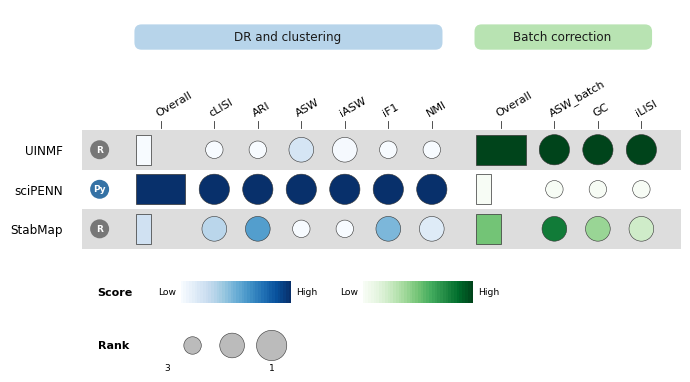

In [13]:
mine.plot()

All three reached CHAIN_OK on this subsample when we ran them. For your real data the only work is producing the
canonical files - `mtb.io.to_canonical` from `.h5ad`, or the h5py pattern above,
plus one label CSV - and these same three calls do the rest.

## 4. Reading stored results

Section 2 ran three methods; the repository ships the **full sweep** for `D52` -
every wired method at default settings, hours of compute - so the paper's
figures reproduce from stored results in seconds. Reading them back is a plain
CSV read, and `mtb.plot.bubble` takes it from there:

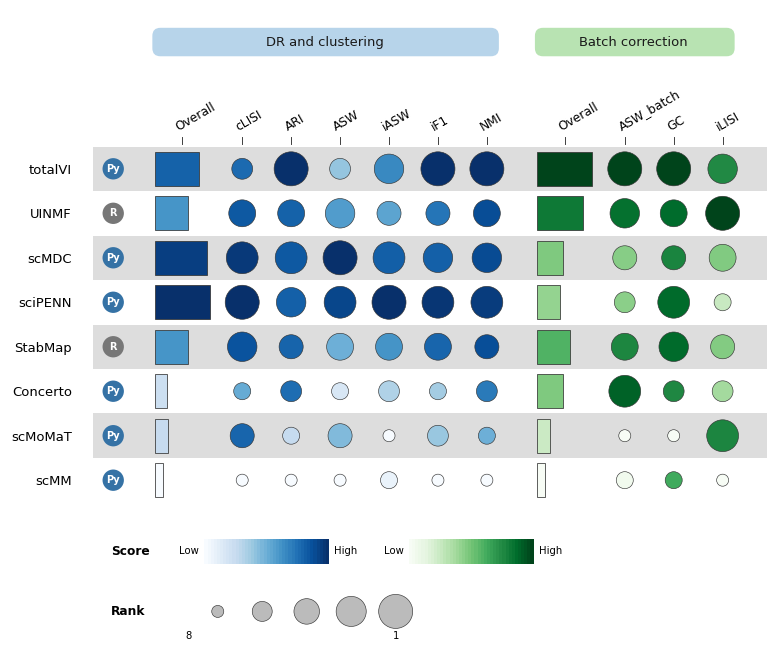

In [14]:
long = pd.read_csv(RESULTS / "long_all_D52.csv")
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
fig

`run_all(DATASET, CATEGORY, out_dir=...)` without `methods=` writes the
same `summary.csv` and `long.csv` for your own data.

**Across datasets.** A summary needs every method to have results on every
dataset it averages over, or absence and performance blur into the same bar. Two
cross datasets therefore ship swept identically - `D52` and `D52s` (a 60% cell
subsample of `D52` under a new name) - and the code below keeps their method
**intersection**, so the matrix is complete by construction. Each bar is the
**grand rank**: the min-max scaled mean rank across the datasets, with length and
colour both carrying it, and `Overall` is the same statistic over the grand ranks.
Both metric families appear because both datasets are multi-batch.

8 methods with results on both datasets


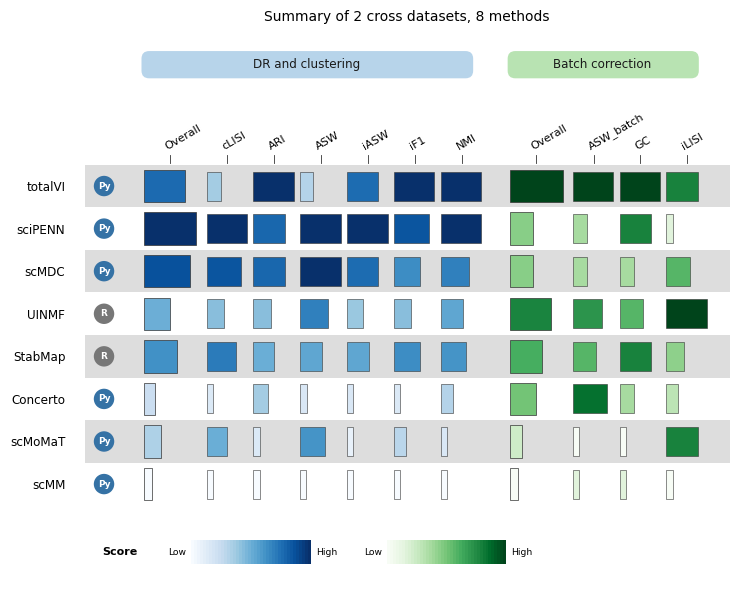

In [15]:
a = pd.read_csv(RESULTS / "long_all_D52.csv").assign(dataset="D52")
b = pd.read_csv(RESULTS / "long_all_D52s.csv").assign(dataset="D52s")
both = sorted(set(a.method) & set(b.method))   # complete matrix, by construction
pair = pd.concat([a, b], ignore_index=True)
pair = pair[pair.method.isin(both)]
print(f"{len(both)} methods with results on both datasets")
mtb.plot.bubble(pair, aggregate="summary",
                title=f"Summary of 2 cross datasets, {len(both)} methods")

## 5. Reference

### What runs on a dataset, and why not

`scan` inspects a folder and reports every runnable method - and for the rest,
the exact reason (missing file, missing environment, wrong layout). Nothing
executes.

In [16]:
avail = mtb.scan(DATASET, category=CATEGORY)
avail[avail.runnable][["method", "modalities", "env", "output_kind",
                       "n_tunable", "runtime_tier"]]

,method,modalities,env,output_kind,n_tunable,runtime_tier
0,Concerto,rna1+rna2+rna3+adt1+adt2+adt3,scmb_concerto,embedding,0,very_slow
1,StabMap,rna1+rna2+rna3+adt1+adt2+adt3,scmb_r,embedding,0,fast
2,UINMF,rna1+rna2+adt1+adt2,scmb_r,embedding,0,fast
3,scMDC,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scmdc,embedding,0,slow
4,scMM,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scmm2,embedding,0,medium
5,scMoMaT,rna1+rna2+rna3+adt1+adt2+adt3,scmb_torch,graph,0,medium
6,sciPENN,rna1+rna2+rna3+adt1+adt2+adt3,env_sciPENN,embedding,0,fast
7,totalVI,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scvi,embedding,0,slow


In [17]:
not_ok = avail[~avail.runnable][["method", "modalities", "reason"]]
not_ok.head(5) if len(not_ok) else "(everything in this category runs here)"


,method,modalities,reason
8,GPSA,(data_dir),spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52
9,PASTE,(data_dir),spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52
10,PASTE2,(data_dir),spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52
11,SPIRAL,(data_dir),spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52


### What each method exposes for tuning

An empty `tunable` is honest: many upstream scripts hardcode their
hyperparameters, and this package never edits upstream code.

In [18]:
from multibench.engine import registry

rows = []
for m in sorted(mtb.list_methods(category=CATEGORY)):
    p = None
    try:
        p = mtb.params_for(m, CATEGORY)
    except Exception:                      # multi-variant: try each variant's modalities
        for v in registry.get(m).variants:
            if v.when.get("category") != CATEGORY:
                continue
            try:
                p = mtb.params_for(m, CATEGORY, v.when.get("modalities"))
                break
            except Exception:
                continue
    if p is None:                          # variant selection needs a concrete dataset
        rows.append({"method": m, "n_tunable": 0, "tunable": "(see scan() on your dataset)"})
        continue
    rows.append({"method": m, "n_tunable": len(p.get("tunable") or {}),
                 "tunable": ", ".join(sorted((p.get("tunable") or {}))[:6])})
pd.DataFrame(rows).sort_values("n_tunable", ascending=False).reset_index(drop=True)

,method,n_tunable,tunable
0,SPIRAL,25,"AEdims, AEdimsR, CLdims, DIdims, GSdims, NUM_NEG"
1,Concerto,0,
2,GPSA,0,
3,Multigrate,0,(see scan() on your dataset)
4,PASTE,0,
5,PASTE2,0,
6,StabMap,0,
7,UINMF,0,
8,scMDC,0,
9,scMM,0,


### The metrics

Two families, matching the paper's grouping. All are **higher = better**, on
[0, 1] except ARI (slightly negative at chance level).

| family | metrics | what they measure |
|---|---|---|
| clustering / bio-conservation | `ARI`, `NMI`, `ASW`, `iASW`, `iF1`, `cLISI` | does the embedding separate the annotated cell types? |
| batch correction | `ASW_batch`, `GC`, `iLISI` (+ opt-in `kBET`) | are the batches mixed within each cell type? |

Batch metrics appear only when the dataset has real batches - their absence on a
single-batch dataset is correct, not missing data. `kBET` is opt-in
(`mtb.evaluate(..., slow_metrics=True)`) because it is much slower than the rest.

### Coverage of the paper

`scan()` answers "what runs on this dataset"; this answers how many of the
methods the paper benchmarks for **cross** the package wires at all.

In [19]:
PAPER = {'vertical': ['totalVI', 'sciPENN', 'Concerto', 'scMSI', 'Matilda', 'MOFA2', 'Multigrate', 'UINMF', 'scMoMaT', 'Seurat_WNN', 'scMM', 'scMDC', 'moETM', 'VIMCCA', 'iPOLNG', 'MIRA', 'UnitedNet', 'scMVP'], 'diagonal': ['scBridge', 'Portal', 'SCALEX', 'VIPCCA', 'Seurat_v3', 'MultiMAP', 'Seurat_v5', 'sciCAN', 'Conos', 'iNMF', 'online_iNMF', 'scJoint', 'GLUE', 'uniPort'], 'mosaic': ['MultiVI', 'scMoMaT', 'StabMap', 'Cobolt', 'UINMF', 'Multigrate', 'SMILE', 'scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN'], 'cross': ['totalVI', 'scMoMaT', 'UnitedNet', 'sciPENN', 'Concerto', 'scMDC', 'StabMap', 'UINMF', 'scMM', 'MOFA2', 'Multigrate', 'PASTE', 'PASTE2', 'SPIRAL', 'GPSA']}
IMPUTATION_ONLY = ['scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN']

paper = PAPER[CATEGORY]
wired = sorted({m for m in mtb.list_methods()
                if any(v.when.get("category") == CATEGORY
                       for v in registry.get(m).variants)})
missing = [m for m in paper if m not in wired]
print(f"paper benchmarks {len(paper)} methods for {CATEGORY}; this package wires {len(wired)}")
if missing:
    print("not wired here:", ", ".join(missing))
    imp = [m for m in missing if m in IMPUTATION_ONLY]
    if imp:
        print("  the paper evaluates these only via IMPUTATION, which is not wired:",
              ", ".join(imp))
else:
    print("full parity with the paper for this category")

paper benchmarks 15 methods for cross; this package wires 12
not wired here: UnitedNet, MOFA2, Multigrate
  the paper evaluates these only via IMPUTATION, which is not wired: UnitedNet


## Troubleshooting

| symptom | meaning | fix |
|---|---|---|
| `scan` says not runnable: input files not found | a required file is absent | the reason names the exact file and lists what IS in the folder |
| `scan` says env missing | that method's conda env is not built | `multibench env install --run` |
| `... looks like cells x features` | matrix stored transposed | re-export with `mtb.io.to_canonical` |
| a method FAILs in seconds | wrong input representation or layout | read `res.failures.iloc[0]["error"]` - the full command line and stderr tail are there |
| a method TIMEOUTs | slow, not broken | raise `timeout=`; runtime tiers in `scan` are measured, not guessed |
| `label_order_confidence` low | several label files fit the cell count | check `label_order_candidates` in the record |

### Spatial registration

`PASTE`, `PASTE2`, `SPIRAL` and `GPSA` are cross-integration methods whose output
is **aligned spatial coordinates**, not an embedding - their status reports
`RUN_OK_NO_EMBEDDING` and clustering metrics genuinely do not apply. Point them
at a directory of spatial slices (see `mtb.scan("D63", category="cross")`).

## Next steps

- the other three tutorials: **vertical**, **diagonal**, **mosaic**
- the hosted interactive explorer: <https://shiny.maths.usyd.edu.au/scMultiBench/> -
  the full benchmark's rankings, browsable without installing anything
- `mtb.method_info(name)` - everything the registry knows about one method
- `mtb.sweep(...)` - one method over a range of one hyperparameter